In [ ]:
'''
PCA,RIDGE,LASSO
This are machine learning algorithms used for data reduction. when timeseries data are so high in dimension this algo used to reduced dimensions.
for more please read the notes.
'''

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Set display options for finance tables
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 1000)

In [6]:
import os
import glob
import numpy as np
import pandas as pd
import yfinance as yf


def load_quant_data(source='yfinance', folder_path=None, csv_path=None, tickers=None, start_date='2018-01-01', end_date='2024-01-01', target_ticker='AAPL', price_col='Close'):
    """
    Ingests financial data from yfinance, a folder of CSVs, or a single CSV file,
    constructing a target return series and a multi-asset lag feature matrix.
    """
    if source == 'yfinance':
        if tickers is None:
            tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'JPM', 'BAC', 'XOM', 'SPY', 'QQQ']
        
        # Download data with auto_adjust
        df = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
        
        # Extract price column safely across yfinance versions
        if isinstance(df.columns, pd.MultiIndex):
            if 'Close' in df.columns.levels[0]:
                df = df['Close']
            elif 'Adj Close' in df.columns.levels[0]:
                df = df['Adj Close']
        else:
            if 'Close' in df.columns:
                df = df[['Close']]
            elif 'Adj Close' in df.columns:
                df = df[['Adj Close']]
                
        df = df.dropna()

    elif source == 'folder':
        if folder_path is None or not os.path.isdir(folder_path):
            raise ValueError(f"Invalid folder path provided: {folder_path}")
            
        csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
        if len(csv_files) == 0:
            raise FileNotFoundError(f"No CSV files found inside folder: {folder_path}")
            
        dfs = []
        for file in csv_files:
            ticker_name = os.path.splitext(os.path.basename(file))[0].upper()
            temp_df = pd.read_csv(file, index_col=0, parse_dates=True)
            
            if price_col in temp_df.columns:
                series = temp_df[price_col].rename(ticker_name)
            elif 'Adj Close' in temp_df.columns:
                series = temp_df['Adj Close'].rename(ticker_name)
            else:
                series = temp_df.iloc[:, 0].rename(ticker_name)
                
            dfs.append(series)
            
        df = pd.concat(dfs, axis=1).sort_index().dropna()

    elif source == 'csv':
        if csv_path is None:
            raise ValueError("csv_path must be provided when source='csv'")
        df = pd.read_csv(csv_path, index_col=0, parse_dates=True)

    else:
        raise ValueError("Source must be 'yfinance', 'folder', or 'csv'")

    # Compute 1-day logarithmic returns
    returns = np.log(df / df.shift(1)).dropna()
    
    # Target (y): Next-day return of target asset (T+1)
    y = returns[target_ticker].shift(-1).rename(f"{target_ticker}_Next_Return")
    
    # Features (X): Lagged returns (T, T-1, T-2)
    feature_lags = []
    for lag in range(0, 3):
        lagged = returns.shift(lag)
        lagged.columns = [f"{col}_lag_{lag}" for col in lagged.columns]
        feature_lags.append(lagged)
        
    X = pd.concat(feature_lags, axis=1)
    
    # Clean and align
    data = pd.concat([X, y], axis=1).dropna()
    
    X_clean = data.drop(columns=[y.name])
    y_clean = data[y.name]
    
    return X_clean, y_clean


# ==============================================================================
# CONFIGURATION SWITCH
# ==============================================================================
USE_FOLDER = False  # Set to True for Folder, False for yfinance

# Parameters for yfinance
YFINANCE_TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'JPM', 'BAC', 'XOM', 'SPY', 'QQQ']

# Parameters for Folder
FOLDER_PATH = r'C:\Users\Pandya Anand\Desktop\market_data'

# Shared Target Ticker
TARGET = 'AAPL'


# ==============================================================================
# AUTOMATIC EXECUTION
# ==============================================================================
if USE_FOLDER:
    X, y = load_quant_data(
        source='folder', 
        folder_path=FOLDER_PATH, 
        target_ticker=TARGET
    )
else:
    X, y = load_quant_data(
        source='yfinance', 
        tickers=YFINANCE_TICKERS, 
        target_ticker=TARGET
    )

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

[*********************100%***********************]  10 of 10 completed

Feature matrix shape: (1505, 30)
Target vector shape: (1505,)


In [7]:
#Step 2: Time-Series Train-Test Split & Pipeline Architecture
# Chronological Split (No random shuffling in Quant workflows)
train_pct = 0.80
split_idx = int(len(X) * train_pct)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training Range: {X_train.index[0].date()} to {X_train.index[-1].date()}")
print(f"Testing Range:  {X_test.index[0].date()} to {X_test.index[-1].date()}")


Training Range: 2018-01-05 to 2022-10-17
Testing Range:  2022-10-18 to 2023-12-28


In [8]:
#Step 3: Quant Model & Dimension Reduction Execution Engine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV, RidgeCV

def run_quant_pipeline(X_train, y_train, X_test, y_test, method='pca', n_components=0.85, cv_folds=5):
    """
    Executes feature extraction/selection using PCA, Lasso, or Ridge.
    Fits Scaler, PCA, and CV penalties strictly on training data to avoid lookahead bias.
    """
    method = method.lower()
    scaler = StandardScaler()
    
    # Fit scaler ONLY on historical training data
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    results = {'scaler': scaler, 'method': method}
    
    if method == 'pca':
        # PCA Dimensionality Reduction
        pca = PCA(n_components=n_components)
        X_train_reduced = pca.fit_transform(X_train_scaled)
        X_test_reduced = pca.transform(X_test_scaled)
        
        results['model'] = pca
        results['X_train_transformed'] = pd.DataFrame(
            X_train_reduced, 
            index=X_train.index, 
            columns=[f"PC_{i+1}" for i in range(X_train_reduced.shape[1])]
        )
        results['X_test_transformed'] = pd.DataFrame(
            X_test_reduced, 
            index=X_test.index, 
            columns=[f"PC_{i+1}" for i in range(X_test_reduced.shape[1])]
        )
        results['explained_variance_ratio'] = pca.explained_variance_ratio_
        print(f"[PCA] Reduced features from {X_train.shape[1]} to {X_train_reduced.shape[1]} principal components.")
        
    elif method == 'lasso':
        # Lasso L1 Feature Selection (Shrinks irrelevant weights to zero)
        lasso = LassoCV(cv=cv_folds, random_state=42, max_iter=10000)
        lasso.fit(X_train_scaled, y_train)
        
        # Filter features with non-zero coefficients
        active_features_mask = lasso.coef_ != 0
        selected_cols = X_train.columns[active_features_mask]
        
        results['model'] = lasso
        results['optimal_alpha'] = lasso.alpha_
        results['coefficients'] = pd.Series(lasso.coef_, index=X_train.columns)
        results['selected_features'] = selected_cols.tolist()
        
        results['X_train_transformed'] = pd.DataFrame(
            X_train_scaled[:, active_features_mask], 
            index=X_train.index, 
            columns=selected_cols
        )
        results['X_test_transformed'] = pd.DataFrame(
            X_test_scaled[:, active_features_mask], 
            index=X_test.index, 
            columns=selected_cols
        )
        print(f"[Lasso] Selected {len(selected_cols)} features out of {X_train.shape[1]} (alpha={lasso.alpha_:.6f}).")

    elif method == 'ridge':
        # Ridge L2 Regularization (Shrinks collinear feature weights)
        ridge = RidgeCV(cv=cv_folds)
        ridge.fit(X_train_scaled, y_train)
        
        results['model'] = ridge
        results['optimal_alpha'] = ridge.alpha_
        results['coefficients'] = pd.Series(ridge.coef_, index=X_train.columns)
        
        results['X_train_transformed'] = pd.DataFrame(
            X_train_scaled, 
            index=X_train.index, 
            columns=X_train.columns
        )
        results['X_test_transformed'] = pd.DataFrame(
            X_test_scaled, 
            index=X_test.index, 
            columns=X_test.columns
        )
        print(f"[Ridge] Retained all {X_train.shape[1]} features with L2 penalty shrinkage (alpha={ridge.alpha_:.6f}).")
        
    else:
        raise ValueError("Invalid method. Select 'pca', 'lasso', or 'ridge'.")

    return results


# ==============================================================================
# EXECUTION LINE (EDIT THIS METHOD VARIABLE TO SWITCH BETWEEN ALGORITHMS):
# ==============================================================================

# Options: 'pca', 'lasso', or 'ridge'
METHOD_CHOICE = 'pca'  # <-- SWITCH METHOD HERE ('pca', 'lasso', 'ridge')

quant_output = run_quant_pipeline(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    y_test=y_test, 
    method=METHOD_CHOICE, 
    n_components=0.85 # Explains 85% of total variance if PCA is selected
)

# View top 5 rows of transformed features
X_train_transformed = quant_output['X_train_transformed']
X_train_transformed.head()

[PCA] Reduced features from 30 to 8 principal components.


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8
Date,,,,,,,,
2018-01-05,-0.920797,0.344943,1.948905,-0.206299,-0.428881,1.023683,-0.591494,-0.263695
2018-01-08,-0.009489,0.196617,1.543098,-0.542860,-0.655503,-0.526281,0.444649,0.018638
2018-01-09,-0.343493,0.789378,1.026817,-0.680681,0.498990,0.069870,-0.259476,0.189423
2018-01-10,-0.175974,0.422322,0.348925,-0.021574,0.466994,0.280108,-0.741232,-0.446734
2018-01-11,-0.566616,-0.553180,0.472766,0.300650,-0.067498,0.153085,0.529328,-0.720477


In [11]:
#Step 4: Execution & Diagnostics

SELECTED_METHOD = 'lasso' # Options: 'pca', 'lasso', 'ridge'

quant_output = run_quant_pipeline(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    y_test=y_test, 
    method=SELECTED_METHOD, 
    n_components=0.85 # Explains 85% of total variance for PCA
)

# Display Transformed Training Output
X_train_reduced = quant_output['X_train_transformed']
X_train_reduced.head()

[Lasso] Selected 25 features out of 30 (alpha=0.000066).


,AAPL_lag_0,BAC_lag_0,GOOGL_lag_0,JPM_lag_0,MSFT_lag_0,NVDA_lag_0,QQQ_lag_0,...,BAC_lag_2,GOOGL_lag_2,JPM_lag_2,MSFT_lag_2,QQQ_lag_2,SPY_lag_2,XOM_lag_2
Date,,,,,,,,,,,,,,,
2018-01-05,0.492136,0.197616,0.653131,-0.323953,0.592198,0.238090,0.580053,...,-0.155100,0.847044,0.043583,0.195208,0.561565,0.440892,0.886968
2018-01-08,-0.227214,-0.316222,0.155876,0.064192,0.007200,0.904645,0.208394,...,0.572808,0.173856,0.692237,0.408892,0.078229,0.286176,0.047455
2018-01-09,-0.054736,0.212754,-0.091455,0.239751,-0.080773,-0.028920,-0.024094,...,0.199974,0.653764,-0.322791,0.593533,0.581274,0.465715,-0.054277
2018-01-10,-0.060248,0.400982,-0.148617,0.528493,-0.280806,0.218786,-0.170185,...,-0.315241,0.155647,0.066034,0.007239,0.208526,0.110813,0.191622
2018-01-11,0.221617,0.151786,0.062852,0.253537,0.107426,0.034156,0.387083,...,0.215153,-0.092113,0.241901,-0.080929,-0.024643,0.142805,-0.214549


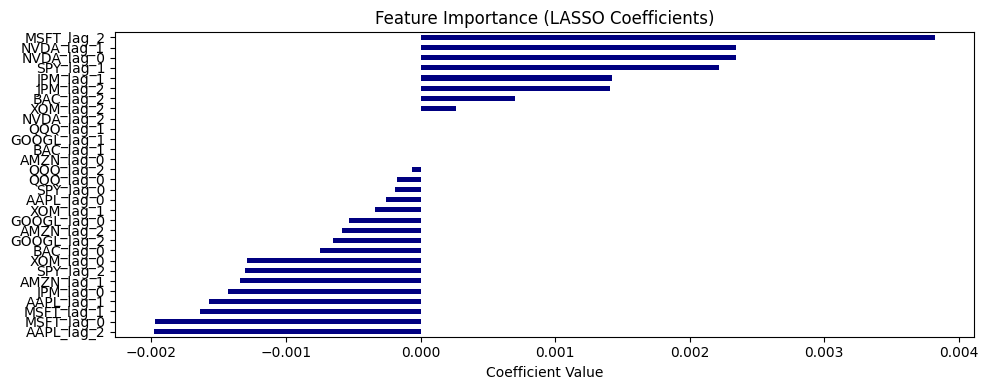

In [12]:
# Visual Diagnostics depending on selected method
plt.figure(figsize=(10, 4))

if SELECTED_METHOD == 'pca':
    cum_var = np.cumsum(quant_output['explained_variance_ratio'])
    plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', linestyle='--')
    plt.axhline(y=0.85, color='r', linestyle=':', label='85% Variance Cutoff')
    plt.title('PCA Cumulative Explained Variance')
    plt.xlabel('Number of Components')
    plt.ylabel('Variance Ratio')
    plt.legend()
    
elif SELECTED_METHOD in ['lasso', 'ridge']:
    coefs = quant_output['coefficients'].sort_values()
    coefs.plot(kind='barh', color='navy')
    plt.title(f'Feature Importance ({SELECTED_METHOD.upper()} Coefficients)')
    plt.xlabel('Coefficient Value')

plt.tight_layout()
plt.show()